# Laporan Modul 4: Exploratory Data Analysis (EDA) Tokopedia Product Reviews 2025

Notebook ini dibuat untuk memenuhi penugasan Modul 4: Exploratory Data Analysis (EDA). Analisis dilakukan menggunakan Python dengan bantuan pustaka Pandas, Matplotlib, dan Seaborn untuk mengeksplorasi tren harga produk, volume penjualan, distribusi kategori, serta sentimen pelanggan berdasarkan dataset ulasan produk Tokopedia.

Kelompok 17 <br>
Anggota:
1.   Abdulhadi Muntashir
2.   Naufal Pancar Nugraha
3.   M Hafid Ramadhan



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset Tugas Data Science M4.rar to Dataset Tugas Data Science M4 (2).rar


In [ ]:
!apt-get install unrar-free -y
!unrar-free x "Dataset Tugas Data Science M4.rar"
!ls

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar-free is already the newest version (1:0.0.2-0.1).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.

unrar 0.0.2  Copyright (C) 2004  Ben Asselstine, Jeroen Dekkers


Extracting from /content/Dataset Tugas Data Science M4.rar

unknown archive type, only plain RAR 2.0 supported(normal and solid archives), SFX and Volumes are NOT supported!
All OK
'Dataset Tugas Data Science M4 (1).rar'   sample_data
'Dataset Tugas Data Science M4 (2).rar'   tokopedia_product_reviews_2025.csv
'Dataset Tugas Data Science M4.rar'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
df = pd.read_csv("tokopedia_product_reviews_2025.csv")

# Ubah review_date ke datetime
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")

# Tampilkan 5 data awal
display(df.head())

# Info dataset
print("Shape dataset:", df.shape)
print("\nInformasi dataset:")
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


Shape dataset: (65543, 13)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   review_text       65543 non-null  object        
 1   review_date       65543 non-null  datetime64[ns]
 2   review_id         65543 non-null  int64         
 3   product_name      65543 non-null  object        
 4   product_category  65543 non-null  object        
 5   product_variant   26749 non-null  object        
 6   product_price     65543 non-null  int64         
 7   product_url       65543 non-null  object        
 8   product_id        65543 non-null  int64         
 9   rating            65543 non-null  int64         
 10  sold_count        65543 non-null  int64         
 11  shop_id           65543 non-null  int64         
 12  sentiment_label   65543 non-null  object        
dtypes: datetime64[ns](1), int64(6

In [ ]:
print(df_clean["sentiment_label"].value_counts())
print(df_clean["product_category"].value_counts())

sentiment_label
positive    23360
neutral       348
negative      298
Name: count, dtype: int64
product_category
Makanan & Minuman    17859
Kesehatan             6147
Name: count, dtype: int64


## Tahap 1: Data Preparation & Overview

Pada tahap awal, dilakukan proses pembacaan dataset, pemeriksaan struktur data, pengecekan tipe data, serta identifikasi missing values. Tahap ini penting untuk memastikan bahwa data sudah siap digunakan dalam proses analisis berikutnya, terutama pada kolom tanggal, harga produk, jumlah penjualan, dan label sentimen.

In [ ]:
# Cek tipe data
print(df.dtypes)

# Cek missing values
missing_values = df.isna().sum().sort_values(ascending=False)
print("\nMissing values per kolom:")
print(missing_values)

# Cleaning sederhana
df_clean = df.copy()

# Pastikan kolom numerik benar
df_clean["product_price"] = pd.to_numeric(df_clean["product_price"], errors="coerce")
df_clean["sold_count"] = pd.to_numeric(df_clean["sold_count"], errors="coerce")

# Drop baris yang kosong pada kolom penting
df_clean = df_clean.dropna(subset=["review_date", "product_price", "sold_count", "sentiment_label", "product_category"])

print("\nShape setelah cleaning:", df_clean.shape)

review_text                 object
review_date         datetime64[ns]
review_id                    int64
product_name                object
product_category            object
product_variant             object
product_price                int64
product_url                 object
product_id                   int64
rating                       int64
sold_count                   int64
shop_id                      int64
sentiment_label             object
dtype: object

Missing values per kolom:
product_variant     38794
review_date             0
review_id               0
product_name            0
review_text             0
product_category        0
product_price           0
product_url             0
product_id              0
rating                  0
sold_count              0
shop_id                 0
sentiment_label         0
dtype: int64

Shape setelah cleaning: (65543, 13)


### Interpretasi 1

Berdasarkan hasil pengecekan missing values, kolom yang memiliki nilai kosong paling banyak adalah `product_variant` (38.794 data kosong). Namun, kolom-kolom utama seperti `review_date`, `product_price`, `sold_count`, dan `sentiment_label` tidak memiliki missing values. Secara khusus, kolom `review_text` memiliki 0 data kosong, sehingga tidak diperlukan strategi imputasi atau penghapusan baris untuk teks ulasan.

Strategi yang digunakan adalah membiarkan kolom `product_variant` tetap apa adanya karena bukan variabel inti analisis. Selain itu, kolom `review_date` dikonversi ke format datetime untuk analisis temporal. Baris dengan nilai kosong pada kolom numerik penting telah dibersihkan menggunakan `dropna` agar tidak mendistorsi hasil perhitungan.


## Tahap 2: Analisis Univariat (Distribusi & Frekuensi)

Tahap ini bertujuan untuk memahami karakteristik dasar dari data. Analisis dilakukan terhadap frekuensi ulasan per kategori produk serta distribusi harga produk di dalam dataset. Visualisasi univariat membantu mengidentifikasi pola dominan, ketimpangan antar kategori, dan sebaran harga pasar secara umum.



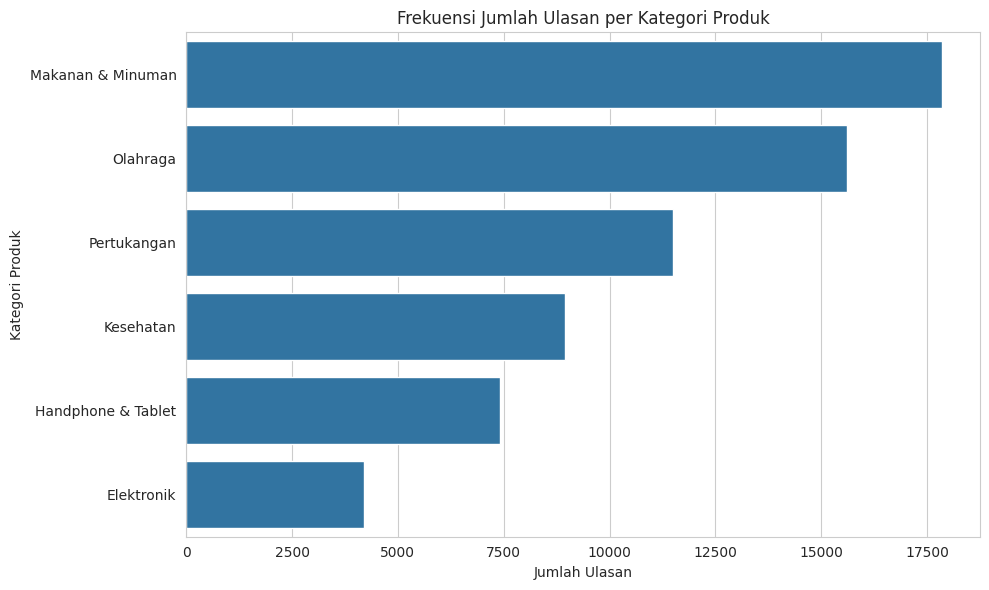

,total_reviews,count
0,Makanan & Minuman,17859
1,Olahraga,15600
2,Pertukangan,11500
3,Kesehatan,8959
4,Handphone & Tablet,7423
5,Elektronik,4202


In [ ]:
category_order = df_clean["product_category"].value_counts().index

plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, y="product_category", order=category_order)

plt.title("Frekuensi Jumlah Ulasan per Kategori Produk")
plt.xlabel("Jumlah Ulasan")
plt.ylabel("Kategori Produk")
plt.tight_layout()
plt.show()

# Tampilkan frekuensi kategorinya juga
display(df_clean["product_category"].value_counts().reset_index().rename(columns={"index":"product_category", "product_category":"total_reviews"}))

### Interpretasi 2

Berdasarkan grafik frekuensi kategori produk, kategori **Makanan & Minuman** merupakan kategori dengan jumlah ulasan terbanyak, disusul oleh **Olahraga** dan **Pertukangan**. Hal ini menunjukkan bahwa aktivitas pelanggan paling tinggi terkonsentrasi pada beberapa kategori tertentu, sehingga distribusi ulasan antar kategori tidak sepenuhnya merata.

Ketimpangan jumlah ulasan ini mengindikasikan bahwa beberapa kategori memiliki eksposur pasar dan interaksi pelanggan yang jauh lebih besar dibanding kategori lain. Oleh karena itu, analisis lanjutan terhadap kategori dengan ulasan terbanyak dapat memberikan insight bisnis yang lebih berdampak.

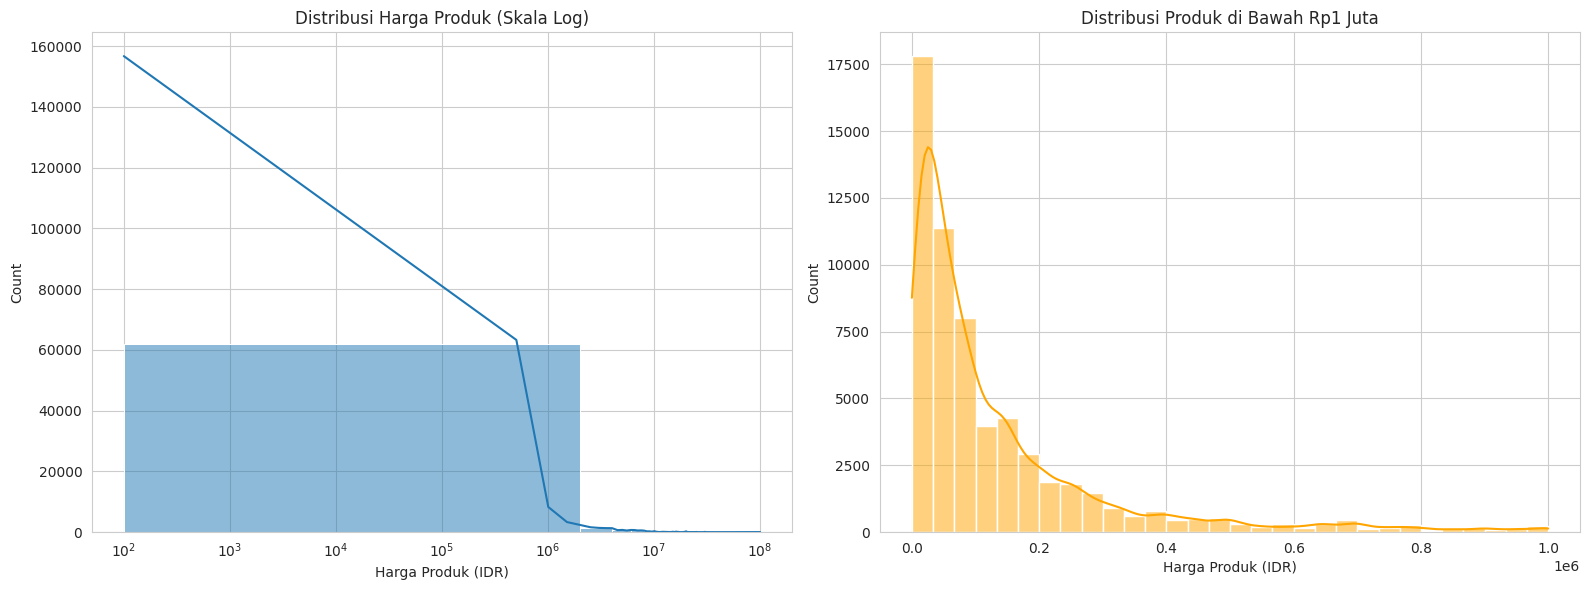

count    6.554300e+04
mean     5.421295e+05
std      2.365557e+06
min      1.000000e+02
25%      2.990000e+04
50%      8.000000e+04
75%      2.146870e+05
max      9.999900e+07
Name: product_price, dtype: float64


In [ ]:
# Membuat dua subplots untuk perbandingan
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distribusi original dengan skala Log (untuk melihat outlier)
sns.histplot(df_clean["product_price"], bins=50, kde=True, ax=ax[0])
ax[0].set_title("Distribusi Harga Produk (Skala Log)")
ax[0].set_xscale("log")
ax[0].set_xlabel("Harga Produk (IDR)")

# Plot 2: Distribusi Produk <= Rp1.000.000 (untuk melihat pasar dominan)
df_filtered = df_clean[df_clean["product_price"] <= 1000000]
sns.histplot(df_filtered["product_price"], bins=30, kde=True, ax=ax[1], color='orange')
ax[1].set_title("Distribusi Produk di Bawah Rp1 Juta")
ax[1].set_xlabel("Harga Produk (IDR)")

plt.tight_layout()
plt.show()

# Menampilkan statistik deskriptif
print(df_clean["product_price"].describe())

### Interpretasi 3

Distribusi harga produk menunjukkan pola yang sangat **right-skewed**, di mana ekor distribusi memanjang jauh ke arah kanan akibat keberadaan produk premium. Meskipun harga maksimum mencapai Rp99.999.000 , mayoritas produk terkonsentrasi pada rentang harga rendah hingga menengah.

Hal ini diperkuat oleh nilai **Median (50%) sebesar Rp80.000**, yang menunjukkan bahwa separuh dari seluruh produk dalam dataset dihargai di bawah angka tersebut. Rentang harga yang paling mendominasi pasar berada pada kelompok produk terjangkau (di bawah Rp214.687 berdasarkan kuartil ketiga). Dengan demikian, strategi agregator sebaiknya tetap berfokus pada volume penjualan produk mass-market, karena produk premium hanya menyumbang fraksi kecil dari total observasi.

## Tahap 3: Deteksi Outlier (Anomali Data)

Pada tahap ini dilakukan analisis distribusi harga produk berdasarkan kategori sentimen pelanggan. Tujuannya adalah untuk melihat apakah terdapat kecenderungan hubungan antara harga produk dengan sentimen yang diberikan, sekaligus mendeteksi keberadaan outlier harga ekstrem pada masing-masing kelompok sentimen.

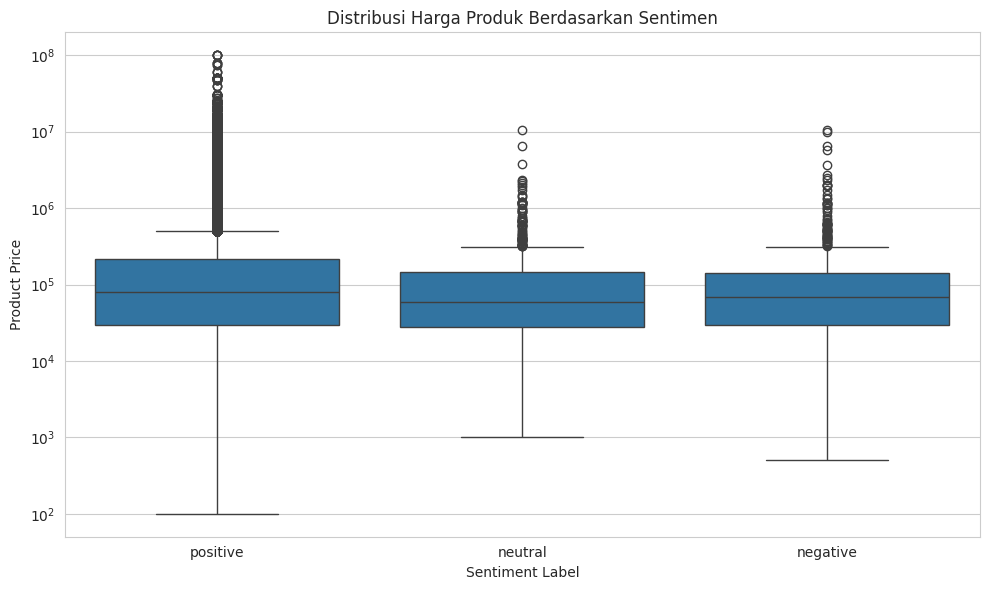

,count,mean,50%,min,max
sentiment_label,,,,,
negative,798.0,185482.943609,68000.0,500.0,10499000.0
neutral,802.0,169813.961347,59000.0,1000.0,10499000.0
positive,63943.0,551250.170245,80500.0,100.0,99999000.0


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean,
    x="sentiment_label",
    y="product_price",
    order=["positive", "neutral", "negative"]
)

plt.title("Distribusi Harga Produk Berdasarkan Sentimen")
plt.xlabel("Sentiment Label")
plt.ylabel("Product Price")
plt.yscale("log")
plt.tight_layout()
plt.show()

display(
    df_clean.groupby("sentiment_label")["product_price"]
    .describe()[["count", "mean", "50%", "min", "max"]]
)

### Interpretasi 4

Boxplot menunjukkan bahwa distribusi harga pada masing-masing kategori sentimen memiliki pola yang cukup bervariasi, namun secara umum produk dengan sentimen **positive** tersebar pada rentang harga yang lebih luas dibanding kelompok **neutral** dan **negative**. Hal ini menunjukkan bahwa produk dengan harga tinggi tidak selalu identik dengan sentimen negatif, karena banyak produk mahal juga tetap memperoleh ulasan positif.

Selain itu, terlihat adanya beberapa **outlier harga ekstrem** di setiap kelompok sentimen, terutama pada sentimen positif. Kehadiran outlier ini menandakan bahwa terdapat produk dengan harga jauh di atas mayoritas data, sehingga seller perlu mengevaluasi apakah produk premium tersebut benar-benar memberikan value yang sesuai dengan ekspektasi pelanggan.

## Tahap 4: Analisis Multivariat (Tren & Korelasi)

Tahap ini berfokus pada dua hal utama, yaitu tren jumlah ulasan dari waktu ke waktu dan hubungan antara harga produk dengan total penjualan. Analisis multivariat membantu memahami pola temporal, dinamika pasar, serta keterkaitan antara harga, performa penjualan, dan sentimen pelanggan.

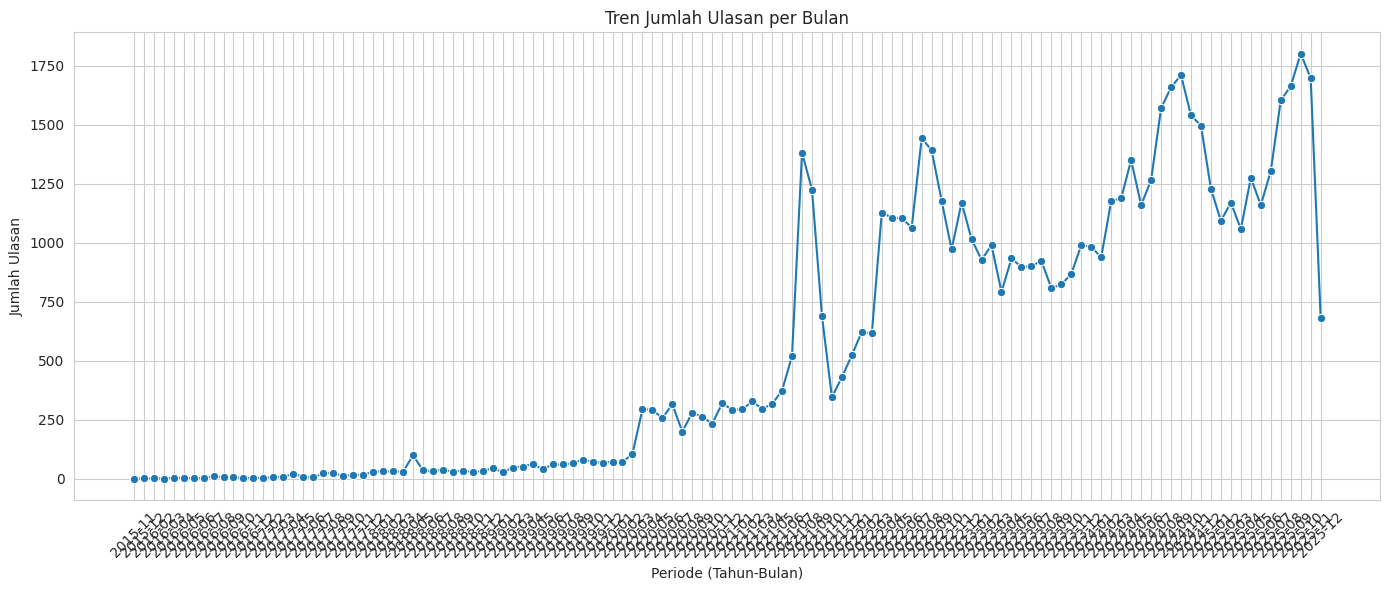

,year_month,total_reviews
117,2025-10,1802
105,2024-10,1711
118,2025-11,1698
116,2025-09,1664
104,2024-09,1659
115,2025-08,1604
103,2024-08,1570
106,2024-11,1540
107,2024-12,1497
79,2022-08,1444


In [ ]:
# Membuat kolom year, month, dan year_month
df_clean["year"] = df_clean["review_date"].dt.year
df_clean["month"] = df_clean["review_date"].dt.month
df_clean["year_month"] = df_clean["review_date"].dt.to_period("M").astype(str)

# Agregasi jumlah ulasan per bulan
monthly_reviews = df_clean.groupby("year_month").size().reset_index(name="total_reviews")

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_reviews, x="year_month", y="total_reviews", marker="o")

plt.title("Tren Jumlah Ulasan per Bulan")
plt.xlabel("Periode (Tahun-Bulan)")
plt.ylabel("Jumlah Ulasan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(monthly_reviews.sort_values("total_reviews", ascending=False).head(10))

### Interpretasi 5

Grafik tren jumlah ulasan per bulan menunjukkan bahwa partisipasi ulasan pelanggan mengalami fluktuasi dari waktu ke waktu, dengan beberapa periode tertentu menampilkan lonjakan yang cukup jelas. Lonjakan ini mengindikasikan adanya momentum transaksi yang lebih tinggi dibanding periode lainnya.

Secara bisnis, kenaikan jumlah ulasan pada bulan-bulan tertentu sangat mungkin berkaitan dengan kampanye promosi marketplace, periode diskon besar, atau meningkatnya aktivitas belanja musiman. Oleh karena itu, seller dapat memanfaatkan periode ramai tersebut untuk mengoptimalkan stok, promosi, dan kualitas layanan agar volume penjualan meningkat tanpa menurunkan kepuasan pelanggan.

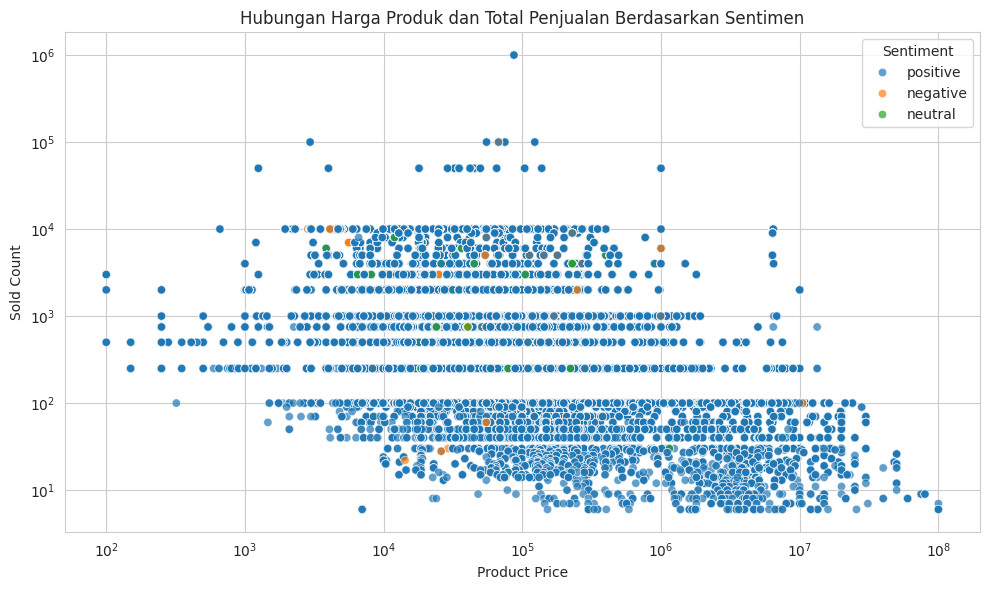

Korelasi Spearman antara product_price dan sold_count: -0.4094472192415116


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="product_price",
    y="sold_count",
    hue="sentiment_label",
    alpha=0.7
)

plt.title("Hubungan Harga Produk dan Total Penjualan Berdasarkan Sentimen")
plt.xlabel("Product Price")
plt.ylabel("Sold Count")
plt.xscale("log")
plt.yscale("log")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

# Korelasi Spearman
corr_spearman = df_clean["product_price"].corr(df_clean["sold_count"], method="spearman")
print("Korelasi Spearman antara product_price dan sold_count:", corr_spearman)

### Interpretasi 6

Scatter plot menunjukkan bahwa hubungan antara harga produk dan total penjualan cenderung **berlawanan arah**, di mana produk dengan harga lebih rendah umumnya memiliki volume penjualan yang lebih tinggi. Hal ini menunjukkan bahwa produk yang terjangkau cenderung lebih mudah menjangkau pasar yang lebih luas.

Dari warna titik berdasarkan sentimen, terlihat bahwa produk dengan penjualan tinggi tidak selalu identik hanya dengan sentimen positif, meskipun sentimen positif tetap mendominasi dataset. Artinya, tingginya volume penjualan belum tentu sepenuhnya mencerminkan kepuasan pelanggan, sehingga seller tetap perlu menjaga kualitas produk dan pengalaman pembelian.

## Tahap 5: Kesimpulan & Rekomendasi Bisnis

Berdasarkan keseluruhan analisis yang telah dilakukan, terdapat beberapa insight utama yang dapat dijadikan dasar dalam pengambilan keputusan bisnis.

### Kesimpulan Akhir

Berdasarkan hasil exploratory data analysis, dapat disimpulkan bahwa aktivitas ulasan pelanggan paling banyak terkonsentrasi pada kategori tertentu, terutama **Makanan & Minuman**, yang menunjukkan bahwa kategori ini memiliki tingkat interaksi pasar yang paling tinggi. Selain itu, distribusi harga produk dalam dataset cenderung didominasi oleh produk murah hingga menengah, sementara produk mahal hanya muncul sebagai sebagian kecil data dan sering terlihat sebagai outlier.

Dari sisi performa bisnis, tren jumlah ulasan memperlihatkan adanya periode-periode tertentu yang mengalami peningkatan aktivitas pelanggan. Hal ini menunjukkan bahwa momentum promosi atau musim belanja memiliki pengaruh terhadap jumlah interaksi dan transaksi. Sementara itu, hubungan antara harga dan jumlah penjualan menunjukkan kecenderungan bahwa produk dengan harga lebih rendah lebih mampu menghasilkan volume penjualan yang tinggi.

Sebagai rekomendasi, seller di Tokopedia sebaiknya lebih fokus mengoptimalkan strategi harga pada produk entry-level hingga middle-range karena segmen ini tampak paling dominan di pasar. Selain itu, seller juga perlu melakukan evaluasi pada produk yang memiliki sentimen netral dan negatif, terutama untuk memastikan bahwa harga yang ditawarkan sudah sebanding dengan kualitas produk dan ekspektasi pelanggan.

Seller juga disarankan untuk memaksimalkan performa toko pada periode dengan lonjakan ulasan, misalnya dengan menyiapkan stok yang cukup, meningkatkan respons layanan pelanggan, dan menjalankan promosi yang lebih agresif. Dengan demikian, peluang peningkatan penjualan dapat dimanfaatkan secara optimal tanpa mengorbankan kepuasan pelanggan.